# Data Preprocessing
Data preprocessing is een cruciale stap in het machine learning-proces, waarbij ruwe gegevens worden omgezet in een geschikt formaat voor modeltraining. Dit omvat verschillende technieken zoals het opschonen van gegevens (verwijderen van ontbrekende waarden of duplicaten), normalisatie of standaardisatie van numerieke waarden, en het coderen van categorische variabelen. Daarnaast kan feature engineering worden toegepast om nieuwe relevante kenmerken te creëren die de prestaties van het model kunnen verbeteren. Een goed uitgevoerde data preprocessing zorgt ervoor dat het model efficiënter kan leren en betere voorspellingen kan doen.

# Dimensionality Reduction
Dimensionality reduction is een techniek die wordt gebruikt om het aantal kenmerken (features) in een dataset te verminderen, terwijl de belangrijkste informatie behouden blijft. Dit is vooral nuttig bij datasets met een hoge dimensie, waar veel kenmerken kunnen leiden tot overfitting en langere trainingstijden. Veelgebruikte methoden voor dimensionality reduction zijn Principal Component Analysis (PCA), t-Distributed Stochastic Neighbor Embedding (t-SNE) en Linear Discriminant Analysis (LDA). Deze technieken helpen bij het identificeren van de meest relevante kenmerken en het visualiseren van gegevens in lagere dimensies, wat kan bijdragen aan een beter begrip van de onderliggende patronen in de data.

Om te beginnen gaan we de nodige libraries importeren en de data inladen. De data is opgeslagen in HDF5 formaat, een veelgebruikt formaat voor het opslaan van grote datasets. 
In de dataset zijn er metingen van 104 verschillende autobanden. Van elk van deze banden zijn er van drie onderdelen metingen gedaan. Het loopvlak, innerliner en zijwand. Elke meting bevat een spectrum van intensiteit over een bereik van golflengtes, samen met een timestamp en een order dat aangeeft of de golflengte binnen het ultra violete spectrum valt of binnen zichtbaar licht. Voor elk onderdeel zijn er zo'n 8000 golflengtes gemeten. In totaal hebben wij dus 104 banden * 3 onderdelen = 312 bestanden met elk 254 metingen, oftewel 79368 metingen in totaal.




In [ ]:
import pandas as pd
import h5py
import os
data_directory = 'data'

We beginnen eerst met het inladen van een enkel bestand om de structuur van de data te begrijpen. Later zullen we een loop schrijven om alle bestanden in te laden en samen te voegen tot één grote dataset.



In [ ]:
# Load the HDF5 file
with h5py.File(r"data\2024-11-05T11-26-41_nr-001_B1_tread_aided_10Hz_280A.h5") as h5:
    intensity = h5['intensity'][:]
    wavelength = h5['wavelength'][:]
    order = h5['order'][:]
    timestamps = h5['timeReceived'][:]

    # Debug: Print shapes to understand the data structure
    print(f"Intensity shape: {intensity.shape}")
    print(f"Wavelength shape: {wavelength.shape}")
    print(f"Order shape: {order.shape}")
    print(f"Timestamps shape: {timestamps.shape}")

# drop the first dimension of timestamps
timestamps = timestamps[1:, :]
timestamps = timestamps.flatten()
print(timestamps.shape)

Intensity shape: (254, 8188)
Wavelength shape: (8188,)
Order shape: (8188,)
Timestamps shape: (2, 254)
(254,)


De shapes van de ingeladen arrays zijn gelijk dus we kunnen ze samenvoegen tot Pandas dataframe.

In [77]:
# Create DataFrame with wavelengths as index
# Assuming intensity is 2D (time x wavelength), we'll aggregate or take first measurement
if intensity.ndim == 2:
    # Option 1: Take mean intensity across time for each wavelength
    mean_intensity = np.mean(intensity, axis=0)
    
    # Option 2: Take first timestamp measurement
    # first_intensity = intensity[0, :]
    
    # Use mean intensity for now
    intensity_values = mean_intensity
else:
    intensity_values = intensity

# Create DataFrame with wavelengths as index
df = pd.DataFrame(index=wavelength)
df.index.name = 'wavelength'

# Add intensity column
df['intensity'] = intensity_values

# Add order column (should match wavelength length)
if len(order) == len(wavelength):
    df['order'] = order
else:
    print(f"Warning: Order length ({len(order)}) doesn't match wavelength length ({len(wavelength)})")
    # Map order values to wavelengths - assuming order corresponds to channels
    # If order has 2 values (UV, VIS), we need to determine which wavelengths belong to which channel
    if len(order) == 2:
        # This is a simplified mapping - you may need to adjust based on your actual data structure
        df['order'] = np.where(wavelength < 400, order[0], order[1])  # UV < 400nm, VIS >= 400nm
    else:
        df['order'] = 0  # fallback

# Add timestamp column
# Since we have timestamps already processed in the previous cell, we can use those
# But we need to match them to wavelengths somehow
if len(timestamps) == len(wavelength):
    # If timestamps length matches wavelengths (unlikely but possible)
    df['timestamp'] = timestamps
elif len(timestamps) > len(wavelength):
    # Take the mean timestamp or first timestamp for each wavelength
    # This assumes timestamps might be repeated for each wavelength
    chunk_size = len(timestamps) // len(wavelength)
    if chunk_size > 0:
        reshaped_timestamps = timestamps[:len(wavelength) * chunk_size].reshape(len(wavelength), -1)
        df['timestamp'] = pd.to_datetime(np.mean(reshaped_timestamps, axis=1), unit='us')
    else:
        df['timestamp'] = timestamps[:len(wavelength)]
else:
    print(f"Warning: Cannot align timestamps (length {len(timestamps)}) with wavelengths (length {len(wavelength)})")
    # Use a single representative timestamp for all wavelengths
    df['timestamp'] = timestamps[0] if len(timestamps) > 0 else pd.NaT

print("DataFrame structure:")
print(df.head())
print(f"\nDataFrame shape: {df.shape}")
print(f"Index (wavelengths): {len(df.index)} values")
print(f"Timestamps type: {type(df['timestamp'].iloc[0]) if not df['timestamp'].isna().all() else 'All NaT'}")

DataFrame structure:
             intensity  order         timestamp
wavelength                                     
184.261658  178.610236      0  1730802401319208
184.334961  137.649606      0  1730802401319208
184.408279  207.807087      0  1730802401319208
184.481567  156.586614      0  1730802401319208
184.554886  227.283465      0  1730802401319208

DataFrame shape: (8188, 3)
Index (wavelengths): 8188 values
Timestamps type: <class 'numpy.int64'>


In [ ]:
df.info(verbose=True)
df.head()
df.describe()

Zo nu hebben wij een dataframe met alle metingen van een het loopvlak van de eerste band. Met een simpele plot gaan we checken of de data er logisch uitziet en dit een goede manier is om de data op te slaan.

<Axes: title={'center': 'Intensity vs Wavelength'}, xlabel='wavelength'>

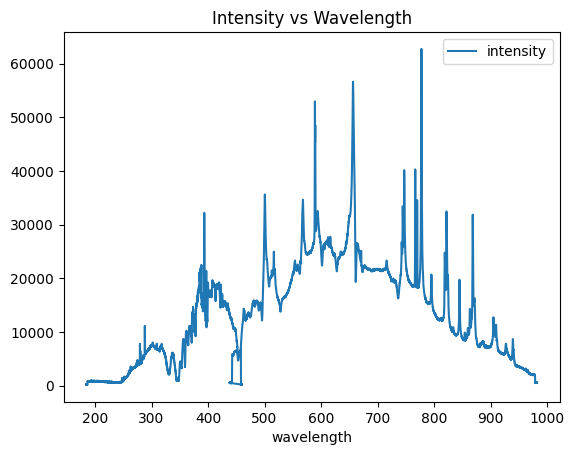

In [86]:
df.plot(y='intensity', kind='line', title='Intensity vs Wavelength')

Dit ziet er goed uit. Nu gaan we de data verdelen over de drie onderdelen van de band om de datakwaliteit te checken

In [106]:
# Lists for each category
tread_files = []
innerliner_files = []
sidewall_files = []

# Loop through all files in the directory
for filename in os.listdir(data_directory):
    filepath = os.path.join(data_directory, filename)

    # Skip if it's not a file (ignore subfolders)
    if not os.path.isfile(filepath):
        continue

    # Categorize based on filename
    if "tread" in filename.lower():
        tread_files.append(filepath)
    elif "innerliner" in filename.lower():
        innerliner_files.append(filepath)
    elif "sidewall" in filename.lower():
        sidewall_files.append(filepath)

#Results
print("Tread files:", len(tread_files))
print("Innerliner files:", len(innerliner_files))
print("Sidewall files:", len(sidewall_files))
# Example: Process the first file in each category
example_files = [tread_files[0], innerliner_files[0], sidewall_files[0]]
print("Example files to process:", example_files)

Tread files: 104
Innerliner files: 104
Sidewall files: 104
Example files to process: ['data\\2024-11-05T11-26-41_nr-001_B1_tread_aided_10Hz_280A.h5', 'data\\2024-11-05T11-28-40_nr-002_B1_innerliner_aided_10Hz_280A.h5', 'data\\2024-11-05T11-30-22_nr-003_B1_sidewall_aided_10Hz_280A.h5']


Dat is gelukt. Nu wil ik de data gaan visualiseren om te checken of er geen vreemde uitschieters in de data zitten.

VOOR MAANDAG -> NIEUWE DATAFRAME MET EXTRA KOLOM MET BANDNUMMER (1-104) (MISSCHIEN DUBBELE INDEX???)